In [1]:
!pip install -q medmnist
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

np.random.seed(42)
tf.random.set_seed(42)


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Experiment 10: Denoising and Dimensionality Reduction for Medical MNIST using Autoencoders
**Aim:** To denoise medical images and reduce them to a 32-dimensional latent space using a convolutional autoencoder (PneumoniaMNIST from MedMNIST).

MSE (noisy vs original):    0.036140938264619095
MSE (denoised vs original): 0.005253433
Dimensionality: 784 -> 32


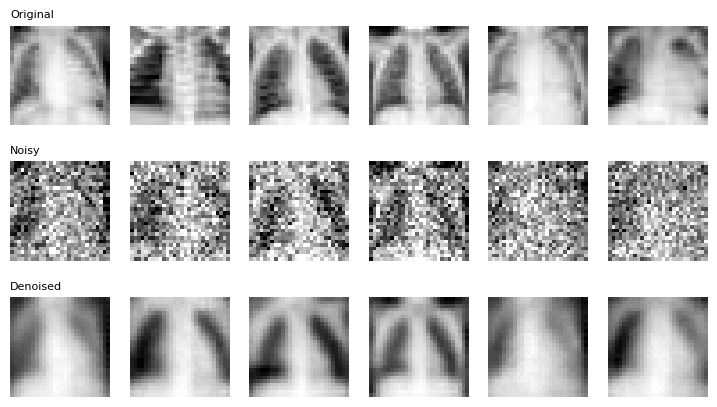

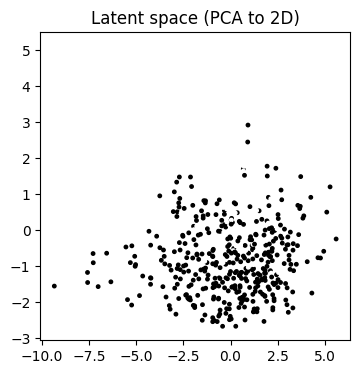

In [2]:
from medmnist import PneumoniaMNIST

train_set = PneumoniaMNIST(split='train', download=True)
test_set = PneumoniaMNIST(split='test', download=True)

Xtr_m = train_set.imgs.astype('float32')[..., None] / 255.0
Xte_m = test_set.imgs.astype('float32')[..., None] / 255.0
yte_m = test_set.labels.ravel()

Xtr_noisy = np.clip(Xtr_m + 0.2 * np.random.randn(*Xtr_m.shape), 0, 1)
Xte_noisy = np.clip(Xte_m + 0.2 * np.random.randn(*Xte_m.shape), 0, 1)

latent_dim = 32
enc_in = layers.Input(shape=(28, 28, 1))
e = layers.Conv2D(16, 3, strides=2, padding='same', activation='relu')(enc_in)
e = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(e)
e = layers.Flatten()(e)
latent = layers.Dense(latent_dim, activation='relu', name='latent')(e)

d = layers.Dense(7 * 7 * 32, activation='relu')(latent)
d = layers.Reshape((7, 7, 32))(d)
d = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(d)
d = layers.Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu')(d)
dec_out = layers.Conv2D(1, 3, strides=1, padding='same', activation='sigmoid')(d)

ae = models.Model(enc_in, dec_out)
encoder = models.Model(enc_in, latent)
ae.compile(optimizer='adam', loss='mse')
ae.fit(Xtr_noisy, Xtr_m, epochs=15, batch_size=128, validation_split=0.1, verbose=0)

recon = ae.predict(Xte_noisy, verbose=0)
print("MSE (noisy vs original):   ", np.mean((Xte_noisy - Xte_m) ** 2))
print("MSE (denoised vs original):", np.mean((recon - Xte_m) ** 2))
print("Dimensionality: 784 ->", latent_dim)

fig, ax = plt.subplots(3, 6, figsize=(9, 5))
for i in range(6):
    ax[0, i].imshow(Xte_m[i, :, :, 0], cmap='gray'); ax[0, i].axis('off')
    ax[1, i].imshow(Xte_noisy[i, :, :, 0], cmap='gray'); ax[1, i].axis('off')
    ax[2, i].imshow(recon[i, :, :, 0], cmap='gray'); ax[2, i].axis('off')
ax[0, 0].set_title('Original', fontsize=8, loc='left')
ax[1, 0].set_title('Noisy', fontsize=8, loc='left')
ax[2, 0].set_title('Denoised', fontsize=8, loc='left')
plt.show()

Z = encoder.predict(Xte_noisy, verbose=0)
Z2 = PCA(n_components=2).fit_transform(Z)
plt.figure(figsize=(4, 4))
plt.scatter(Z2[:, 0], Z2[:, 1], c=yte_m, s=6, cmap='gray_r')
plt.title('Latent space (PCA to 2D)')
plt.show()